## Correlation

In [49]:
#Generate Sinusoids

import numpy as np
import matplotlib.pyplot as plt
# Generate a few sinusoids

samplerate = 1000  # 1000 points every second
# 1 second of audio
timeAxis  = np.linspace(0, 1, samplerate)
freq1 = 5
freq2 = 10
freq3 = 25

sineWave1 = 0.5*np.sin(2*np.pi*freq1*timeAxis)
sineWave2 = 0.5*np.sin(2*np.pi*freq2*timeAxis)
sineWave3 = 0.5*np.sin(2*np.pi*freq3*timeAxis)

# Sum of SineWaves
sineWaveSum = sineWave1 + sineWave2 + sineWave3
sineWaveSum = sineWaveSum/np.max(sineWaveSum)

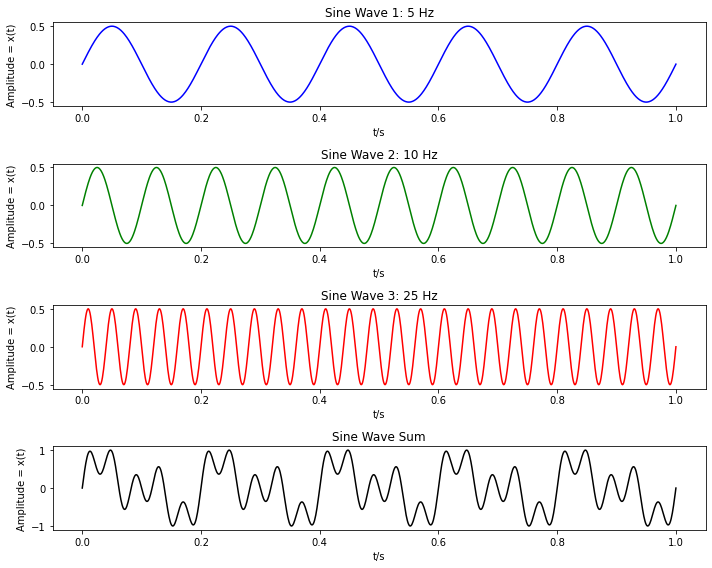

In [50]:
# Create subplots
fig, axes = plt.subplots(4, 1, figsize=(10, 8))  # 4 rows, 1 column

# Plot each sine wave in its respective subplot
axes[0].plot(timeAxis, sineWave1, color='b')
axes[0].set_title(f'Sine Wave 1: {freq1} Hz')
axes[0].set_xlabel('t/s')
axes[0].set_ylabel('Amplitude = x(t)')

axes[1].plot(timeAxis, sineWave2, color='g')
axes[1].set_title(f'Sine Wave 2: {freq2} Hz')
axes[1].set_xlabel('t/s')
axes[1].set_ylabel('Amplitude = x(t)')

axes[2].plot(timeAxis, sineWave3, color='r')
axes[2].set_title(f'Sine Wave 3: {freq3} Hz')
axes[2].set_xlabel('t/s')
axes[2].set_ylabel('Amplitude = x(t)')

axes[3].plot(timeAxis, sineWaveSum, color='k')
axes[3].set_title(f'Sine Wave Sum')
axes[3].set_xlabel('t/s')
axes[3].set_ylabel('Amplitude = x(t)')


# Clean
plt.tight_layout()
plt.show()

### Implementing cross correlation

In [52]:
# Correlation of the 5Hz SineWave with our sum of Sinusoidals
cross_corr = np.correlate(sineWaveSum, sineWave1, mode='full')

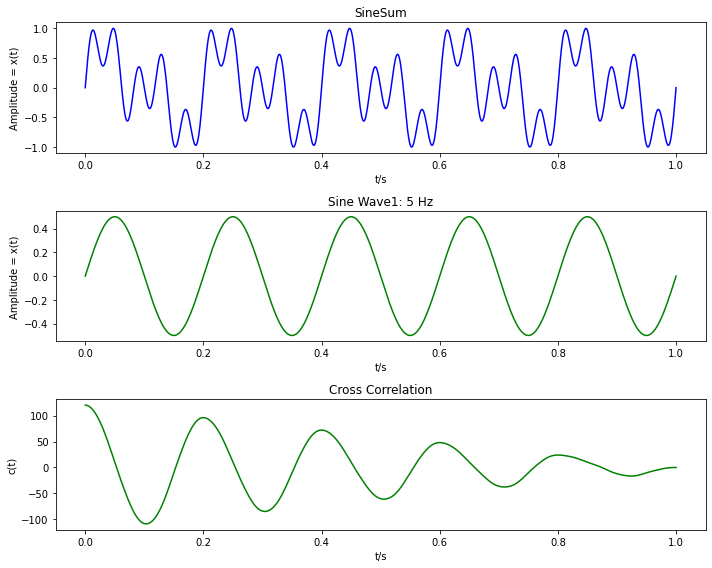

In [53]:
# Create subplots
fig, axes = plt.subplots(3, 1, figsize=(10, 8))  # 4 rows, 1 column

# Plot each sine wave in its respective subplot
axes[0].plot(timeAxis, sineWaveSum, color='b')
axes[0].set_title(f'SineSum')
axes[0].set_xlabel('t/s')
axes[0].set_ylabel('Amplitude = x(t)')

axes[1].plot(timeAxis, sineWave1, color='g')
axes[1].set_title(f'Sine Wave1: {freq1} Hz')
axes[1].set_xlabel('t/s')
axes[1].set_ylabel('Amplitude = x(t)')

axes[2].plot(timeAxis, cross_corr[999:1999], color='g')
axes[2].set_title(f'Cross Correlation')
axes[2].set_xlabel('t/s')
axes[2].set_ylabel('c(t)')


# Clean
plt.tight_layout()
plt.show()

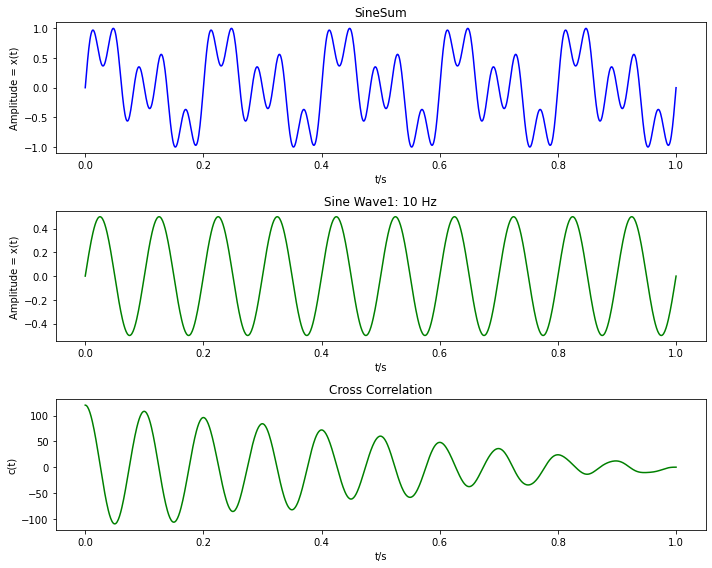

In [54]:
# Correlation of the 10Hz SineWave with our sum of Sinusoidals
cross_corr = np.correlate(sineWaveSum, sineWave2, mode='full')

# Create subplots
fig, axes = plt.subplots(3, 1, figsize=(10, 8))  # 3 rows, 1 column

# Plot each sine wave in its respective subplot
axes[0].plot(timeAxis, sineWaveSum, color='b')
axes[0].set_title('SineSum')
axes[0].set_xlabel('t/s')
axes[0].set_ylabel('Amplitude = x(t)')

axes[1].plot(timeAxis, sineWave2, color='g')
axes[1].set_title(f'Sine Wave1: {freq2} Hz')
axes[1].set_xlabel('t/s')
axes[1].set_ylabel('Amplitude = x(t)')

axes[2].plot(timeAxis, cross_corr[999:1999], color='g')
axes[2].set_title(f'Cross Correlation')
axes[2].set_xlabel('t/s')
axes[2].set_ylabel('c(t)')


# Clean
plt.tight_layout()
plt.show()

## Complex Oscillation

Practical python demonstration for: https://ringbuffer.org/dsp/Fourier_Transform/discrete-fourier-transform/


$$e^{-j 2πkn/N}$$
where,
$$e^{-j 2πkn/N} = cos(2πkn/N) - j·sin(2πkn/N)$$

Where:
k = frequency bin index

n = time index

N = total number of samples

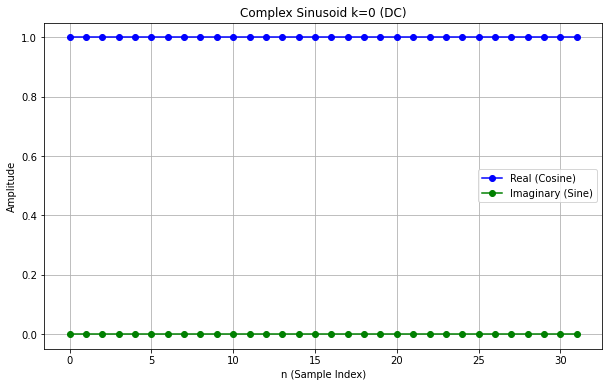

In [55]:
import numpy as np
import matplotlib.pyplot as plt

# Total samples of 32
N = 32
n = np.arange(N)

# Generate a complex Sinusoid
k0 = np.exp(-1j * 2 * np.pi * 0 * n / N)  # DC
cosine = k0.real
sine = k0.imag

# Create subplot
plt.figure(figsize=(10, 6))
plt.plot(n, cosine, 'b-o', label='Real (Cosine)')
plt.plot(n, sine, 'g-o', label='Imaginary (Sine)')
plt.title('Complex Sinusoid k=0 (DC)')
plt.xlabel('n (Sample Index)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()

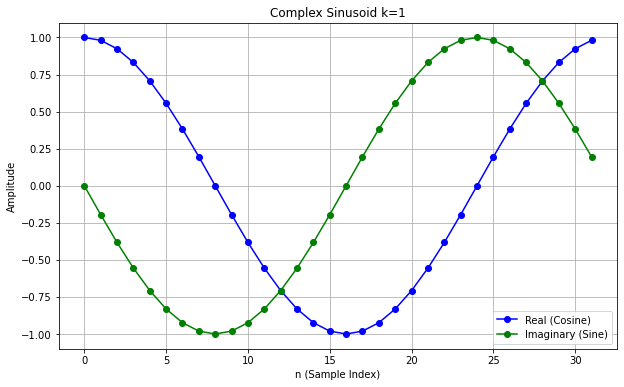

In [56]:
# Generate a complex Sinusoid
k1 = np.exp(-1j * 2 * np.pi * 1 * n / N)  # First Harmonic
cosine = k1.real
sine = k1.imag

# Create subplot
plt.figure(figsize=(10, 6))
plt.plot(n, cosine, 'b-o', label='Real (Cosine)')
plt.plot(n, sine, 'g-o', label='Imaginary (Sine)')
plt.title('Complex Sinusoid k=1')
plt.xlabel('n (Sample Index)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()

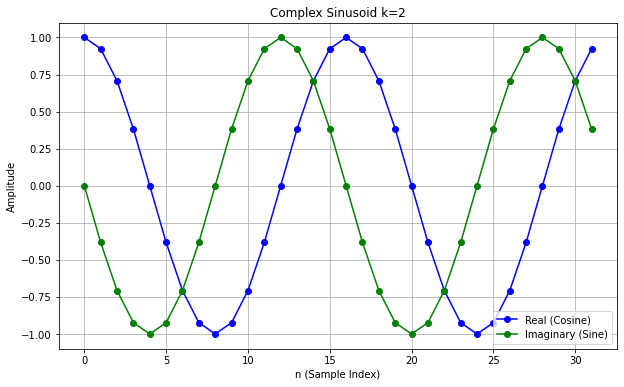

In [58]:
# Generate a complex Sinusoid
k2 = np.exp(-1j * 2 * np.pi * 2 * n / N)  # Second Harmonic
cosine = k2.real
sine = k2.imag

# Create subplot
plt.figure(figsize=(10, 6))
plt.plot(n, cosine, 'b-o', label='Real (Cosine)')
plt.plot(n, sine, 'g-o', label='Imaginary (Sine)')
plt.title('Complex Sinusoid k=2')
plt.xlabel('n (Sample Index)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()

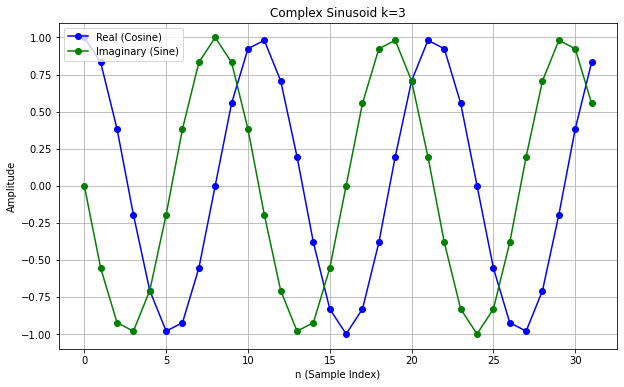

In [80]:
# Generate a complex Sinusoid
k3 = np.exp(-1j * 2 * np.pi * 3 * n / N)
cosine = k3.real
sine = k3.imag

# Create subplot
plt.figure(figsize=(10, 6))
plt.plot(n, cosine, 'b-o', label='Real (Cosine)')
plt.plot(n, sine, 'g-o', label='Imaginary (Sine)')
plt.title('Complex Sinusoid k=3')
plt.xlabel('n (Sample Index)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()

### DFT

$$X[k] = ∑(n=0 to N-1) x[n]·e^{-j2πkn/N}$$

Can be viewed as:
$$X[k] = <x[n], e^{-j2πkn/N}>$$

Where:
- x[n] is the input signal
- $e^{-j2πkn/N}$ is the basis function
- k is the frequency bin
- N is the number of samples
- <·,·> denotes inner product/correlation

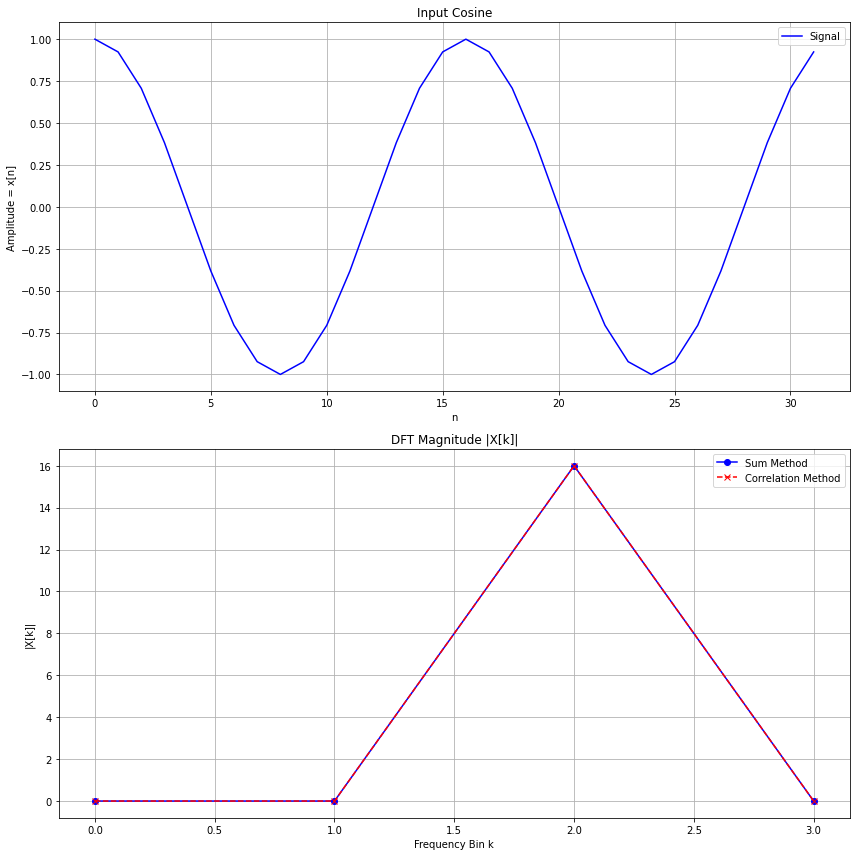

In [84]:
# Generate sample points
N = 32
n = np.arange(N)

# Generate example signal (you can replace this with your actual signal)
x = np.cos(2 * np.pi * 2 * n / N)

# Generate basis functions
kComplex = [np.exp(-1j * 2 * np.pi * k * n / N) for k in range(4)]

# Initialize arrays with complex dtype
X_sum = np.zeros(len(kComplex), dtype=complex)
X_corr = np.zeros(len(kComplex), dtype=complex)

for kInd, k in enumerate(kComplex):
    # Method 1: Using the Formula
    X_sum[kInd] = np.sum(x * k)
    
    # Method 2: Using correlation
    X_corr[kInd] = np.correlate(x, k, mode='full')[N-1]

# Create subplots
fig, axes = plt.subplots(2, 1, figsize=(12, 12))

# Plot input signal
axes[0].plot(n, x, 'b-', label='Signal')
axes[0].set_title('Input Cosine')
axes[0].set_xlabel('n')
axes[0].set_ylabel('Amplitude = x[n]')
axes[0].grid(True)
axes[0].legend()

# Plot DFT magnitudes from both methods
k_vals = np.arange(4)
axes[1].plot(k_vals, np.abs(X_sum), 'b-o', label='Sum Method')
axes[1].plot(k_vals, np.abs(X_corr), 'r--x', label='Correlation Method')
axes[1].set_title('DFT Magnitude |X[k]|')
axes[1].set_xlabel('Frequency Bin k')
axes[1].set_ylabel('|X[k]|')
axes[1].grid(True)
axes[1].legend()


plt.tight_layout()
plt.show()